# 35. Eigenvalue Theory and Localization

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. Explain why **no finite algorithm** computes eigenvalues, and reduce the question to
   Abel and Galois through the companion matrix.
2. Use **Gerschgorin's theorem** to locate eigenvalues, and say when the bound is tight and when
   it says nothing.
3. Get a second free region from the **columns**, and a sharper one from **Brauer's** Cassini
   ovals.
4. Recognise the case where Gerschgorin becomes an **exact count**: disjoint discs.
5. Compute the **individual** condition number $1/|\mathbf{y}^H\mathbf{x}|$ of each eigenvalue,
   and say why one number for the whole matrix is not enough.
6. State **Bauer-Fike**, use it, and say where it is vacuous.
7. Explain why a **defective** eigenvalue is not merely ill conditioned but conditioned at a
   different rate, $\varepsilon^{1/m}$ rather than $\varepsilon$.
8. State why every algorithm targets the **Schur form** rather than the eigendecomposition, and
   why every algorithm uses **orthogonal** similarities only.

## Prerequisites

Lesson 15 (norms and condition numbers). Lesson 19 (conditioning against stability). Lesson 06
(polynomial root conditioning, which this lesson connects to eigenvalues). Lesson 31
(orthogonal transformations, used here as the only permitted similarity).

---

## 1. Why there is no formula

Every method so far has been finite: Gaussian elimination takes $n^3/3$ operations and stops,
QR takes $2mn^2$ and stops. **Eigenvalues cannot be computed that way, and the obstruction is a
theorem rather than a gap in anyone's cleverness.**

The reduction is one line. Given a monic polynomial

$$p(t) = t^n + c_{n-1}t^{n-1} + \cdots + c_1t + c_0,$$

its **companion matrix** has $p$ as its characteristic polynomial, so the roots of $p$ are the
eigenvalues of a matrix.

**Therefore a finite eigenvalue algorithm would be a finite root formula.** If some procedure
computed eigenvalues in finitely many additions, multiplications, divisions and root
extractions, applying it to the companion matrix would express the roots of any polynomial in
radicals. **Abel and Galois proved that impossible for degree 5 and above.**

So every eigenvalue method in Part 6 is **iterative**, and the questions become: where should I
look, how fast does it converge, and when do I stop.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import eigen

print("the companion matrix of t^2 - 3t + 2, whose roots are 1 and 2:")
C = eigen.companion_matrix([2.0, -3.0])
print(C)
print("eigenvalues:", np.sort(np.linalg.eigvals(C).real))

print(f"\n{'degree':>8}{'roots recovered to':>21}{'kappa(companion)':>19}"
      f"{'radicals exist':>17}")
for degree in (2, 3, 4, 5, 8, 12):
    out = eigen.no_finite_algorithm(degree, np.random.default_rng(1))
    print(f"{degree:>8}{out['max_difference']:>21.2e}{out['kappa_companion']:>19.2e}"
          f"{str(out['solvable_in_radicals']):>17}")
    assert out["max_difference"] < 1e-9

the companion matrix of t^2 - 3t + 2, whose roots are 1 and 2:
[[ 0. -2.]
 [ 1.  3.]]
eigenvalues: [1. 2.]

  degree   roots recovered to   kappa(companion)   radicals exist
       2             0.00e+00           5.19e+01             True
       3             4.44e-16           6.33e+01             True
       4             1.48e-13           1.43e+02             True
       5             7.79e-14           2.28e+02            False
       8             1.32e-13           4.30e+03            False
      12             1.67e-13           6.28e+05            False


**The equivalence is exact in both directions.** Roots to eigenvalues is the companion matrix;
eigenvalues to roots is the characteristic polynomial. So the two problems are the same problem,
and the impossibility transfers.

**Two things this does not say.** It does not say eigenvalues are hard to approximate: the
methods of lessons 36 to 39 converge fast. And it does not recommend the companion matrix as a
root finder. Its condition number grows quickly with the degree, which lesson 06 already warned
about, and the last column of the table shows it: $\kappa$ rises from $52$ to
$6.3\times10^{5}$ over ten degrees.

---

## 2. Gerschgorin: where to look

**Theorem.** Every eigenvalue of $A$ lies in the union of the discs

$$D_i = \Big\{z : |z - a_{ii}| \le \sum_{j\ne i}|a_{ij}|\Big\}, \qquad i = 1,\dots,n.$$

**The proof is three lines and it explains the theorem.** Let $A\mathbf{x} = \lambda\mathbf{x}$
and let $i$ be the index of the largest entry of $\mathbf{x}$. Row $i$ says

$$(\lambda - a_{ii})x_i = \sum_{j\ne i}a_{ij}x_j.$$

Dividing by $x_i$, which is the largest, and using $|x_j/x_i| \le 1$:

$$|\lambda - a_{ii}| \le \sum_{j\ne i}|a_{ij}|.$$

**So the bound is tight exactly when the eigenvector is concentrated on one entry.** For a
nearly diagonal matrix it is sharp; for a matrix whose eigenvectors are spread out it is loose.
That is the whole story of when to trust it.

In [3]:
# A diagonally dominant matrix: Gerschgorin should be sharp.
n = 6
dominant = np.diag(np.arange(1.0, n + 1) * 10.0) + 0.4 * rng.standard_normal((n, n))
np.fill_diagonal(dominant, np.arange(1.0, n + 1) * 10.0)

report = eigen.localization_report(dominant)
discs = eigen.gerschgorin_discs(dominant)
print("diagonally dominant, disc centres and radii:")
for d in discs:
    lam = min(report["eigenvalues"], key=lambda v: abs(v - d.centre))
    print(f"  centre {d.centre.real:7.3f}  radius {d.radius:6.3f}   "
          f"nearest eigenvalue {lam.real:8.4f}   distance {abs(lam - d.centre):.4f}")
print(f"\nall eigenvalues inside: {report['rows_contain_all']}")
print(f"discs disjoint from all others: {eigen.disjoint_disc_count(dominant)} of {n}")
assert report["rows_contain_all"]

diagonally dominant, disc centres and radii:
  centre  10.000  radius  2.394   nearest eigenvalue  10.0027   distance 0.0027
  centre  20.000  radius  1.062   nearest eigenvalue  20.0007   distance 0.0007
  centre  30.000  radius  1.352   nearest eigenvalue  29.9933   distance 0.0067
  centre  40.000  radius  0.996   nearest eigenvalue  39.9995   distance 0.0005
  centre  50.000  radius  0.844   nearest eigenvalue  50.0066   distance 0.0066
  centre  60.000  radius  1.796   nearest eigenvalue  59.9971   distance 0.0029

all eigenvalues inside: True
discs disjoint from all others: 6 of 6


**Every disc is disjoint here, and that upgrades the theorem.** Read on.

---

## 3. Disjoint discs make it exact

**The refinement.** If a group of $k$ discs is disjoint from the remaining $n-k$, that group
contains **exactly** $k$ eigenvalues, counted with multiplicity.

The proof is continuity. Interpolate $A(t) = D + t(A - D)$ from the diagonal part $D$ to $A$.
At $t=0$ the eigenvalues sit at the disc centres. As $t$ grows the eigenvalues move
continuously and each stays inside the discs of $A(t)$, which are the discs of $A$ shrunk by
$t$. **Eigenvalues cannot jump between disjoint components**, so the count in each component
never changes.

**That turns a region into an error bound.** A disc disjoint from all the others contains
exactly one eigenvalue, and its radius is a rigorous bound on the distance from the centre.

In [4]:
print(f"{'i':>3}{'a_ii':>10}{'radius':>10}{'eigenvalue':>14}{'actual error':>15}"
      f"{'bound holds':>13}")
vals = np.sort(np.linalg.eigvals(dominant).real)
centres = np.sort(np.diag(dominant))
for i, (c, lam) in enumerate(zip(centres, vals)):
    d = next(dd for dd in discs if abs(dd.centre.real - c) < 1e-12)
    err = abs(lam - c)
    print(f"{i:>3}{c:>10.3f}{d.radius:>10.4f}{lam:>14.5f}{err:>15.6f}"
          f"{str(err <= d.radius):>13}")
    assert err <= d.radius
print("\nEach radius is a genuine error bound because the discs are disjoint.")

  i      a_ii    radius    eigenvalue   actual error  bound holds
  0    10.000    2.3937      10.00272       0.002716         True
  1    20.000    1.0620      20.00071       0.000708         True
  2    30.000    1.3521      29.99332       0.006677         True
  3    40.000    0.9961      39.99953       0.000475         True
  4    50.000    0.8436      50.00663       0.006627         True
  5    60.000    1.7960      59.99710       0.002899         True

Each radius is a genuine error bound because the discs are disjoint.


**Notice how much smaller the actual errors are than the radii.** The bound is rigorous and it
is not sharp, and both facts matter: you can rely on it, and you should not read it as an
estimate.

---

## 4. Two free improvements

**The columns.** $A$ and $A^T$ have the same eigenvalues, so the discs built from **column**
sums are equally valid. That is a second region for the cost of a transpose, and the eigenvalues
lie in the **intersection** of the two unions, which can be much smaller than either.

**Brauer's ovals.** For each pair $i\ne j$, every eigenvalue lies in the union of the Cassini
ovals

$$K_{ij} = \{z : |z-a_{ii}|\,|z-a_{jj}| \le r_ir_j\}.$$

**Brauer's union is contained in Gerschgorin's**, always. The cost is $n(n-1)/2$ regions instead
of $n$, and each is an oval rather than a disc.

In [5]:
# A matrix where the row and column pictures differ a lot.
lopsided = np.diag([1.0, 5.0, 9.0, 13.0]).astype(float)
lopsided[0, 1:] = 3.0                      # row 0 is fat, its column is thin
lopsided[1:, 0] = 0.05

row_discs = eigen.gerschgorin_discs(lopsided)
col_discs = eigen.gerschgorin_discs(lopsided, by_columns=True)
print(f"{'i':>3}{'centre':>9}{'row radius':>13}{'column radius':>16}")
for r, c in zip(row_discs, col_discs):
    print(f"{r.index:>3}{r.centre.real:>9.2f}{r.radius:>13.4f}{c.radius:>16.4f}")

rep = eigen.localization_report(lopsided)
print(f"\nrow union area bound    : {rep['row_area_bound']:8.3f}")
print(f"column union area bound : {rep['column_area_bound']:8.3f}")
print(f"the columns are {rep['row_area_bound'] / rep['column_area_bound']:.1f} times tighter here")
print(f"\nall eigenvalues in the row discs    : {rep['rows_contain_all']}")
print(f"all eigenvalues in the column discs : {rep['columns_contain_all']}")
print(f"all eigenvalues in the Brauer ovals  : {rep['ovals_contain_all']}")
assert rep["rows_contain_all"] and rep["columns_contain_all"] and rep["ovals_contain_all"]

  i   centre   row radius   column radius
  0     1.00       9.0000          0.1500
  1     5.00       0.0500          3.0000
  2     9.00       0.0500          3.0000
  3    13.00       0.0500          3.0000

row union area bound    :  254.493
column union area bound :   84.894
the columns are 3.0 times tighter here

all eigenvalues in the row discs    : True
all eigenvalues in the column discs : True
all eigenvalues in the Brauer ovals  : True


**Take the transpose before concluding a matrix is hard to localize.** It costs nothing and here
the column region is 3.0 times smaller by area. Row 0 is fat and its column is thin, so the two
pictures disagree about which eigenvalue is well located, and the intersection is better than
either.

**And check that Brauer really is contained in Gerschgorin**, rather than taking it on trust:

In [6]:
gen = np.random.default_rng(5)
test = gen.standard_normal((5, 5))
discs_t = eigen.gerschgorin_discs(test)
ovals_t = eigen.brauer_ovals(test)
span = max(abs(d.centre) for d in discs_t) + max(d.radius for d in discs_t)

in_oval = in_both = 0
for _ in range(20000):
    z = complex(gen.uniform(-span, span), gen.uniform(-span, span))
    if any(eigen.in_brauer_oval(z, o) for o in ovals_t):
        in_oval += 1
        in_both += int(any(d.contains(z, tol=1e-7) for d in discs_t))
print(f"of {in_oval} sampled points inside some Brauer oval,")
print(f"{in_both} were also inside some Gerschgorin disc: "
      f"{in_both / max(in_oval, 1):.1%}")
assert in_both == in_oval, "Brauer must be contained in Gerschgorin"
print(f"\nand the Brauer region is smaller: it caught {in_oval} of 20000 samples,")
print(f"while Gerschgorin caught "
      f"{sum(any(d.contains(complex(gen.uniform(-span, span), gen.uniform(-span, span)), tol=1e-7) for d in discs_t) for _ in range(20000))}")

of 9472 sampled points inside some Brauer oval,
9472 were also inside some Gerschgorin disc: 100.0%

and the Brauer region is smaller: it caught 9472 of 20000 samples,


while Gerschgorin caught 18270


---

## 5. Conditioning: each eigenvalue has its own

Let $\mathbf{x}$ be a right eigenvector and $\mathbf{y}$ a **left** eigenvector for the same
$\lambda$, both of unit length. Perturbing $A$ by $E$ moves $\lambda$ by

$$\delta\lambda \approx \frac{\mathbf{y}^HE\mathbf{x}}{\mathbf{y}^H\mathbf{x}},
\qquad\text{so}\qquad |\delta\lambda| \lesssim \frac{\|E\|}{|\mathbf{y}^H\mathbf{x}|}.$$

**The condition number of $\lambda$ is $1/|\mathbf{y}^H\mathbf{x}|$**, the reciprocal cosine of
the angle between its left and right eigenvectors.

**For a symmetric matrix the two coincide**, so $\mathbf{y}^H\mathbf{x} = 1$ and every
eigenvalue has condition number exactly 1. **That single fact is why lessons 37 and 38 split the
problem in two.**

In [7]:
def symmetrise(M):
    return M + M.T


def strongly_non_normal(size, strength=8.0):
    """Distinct eigenvalues on the diagonal, large entries above it, so the eigenvectors are
    nearly parallel and the left and right ones point in very different directions."""
    return np.triu(np.ones((size, size)), 1) * strength + np.diag(np.arange(1.0, size + 1))


size = 6
families = [("symmetric", symmetrise(rng.standard_normal((size, size)))),
            ("random nonsymmetric", rng.standard_normal((size, size))),
            ("triangular, distinct diagonal",
             np.triu(rng.standard_normal((size, size)), 1) + np.diag(np.arange(1.0, size + 1))),
            ("strongly non-normal", strongly_non_normal(size))]

print(f"{'matrix':>32}{'kappa(V)':>12}{'worst kappa_i':>15}{'best kappa_i':>15}"
      f"{'spread':>10}")
for name, M in families:
    c = eigen.eigenvalue_condition_numbers(M)
    kv = eigen.bauer_fike_bound(M)["kappa_V"]
    print(f"{name:>32}{kv:>12.3e}{c['worst']:>15.3e}{c['best']:>15.3e}"
          f"{c['worst'] / c['best']:>10.1f}")

sym_conds = eigen.eigenvalue_condition_numbers(families[0][1])["condition_numbers"]
assert np.allclose(sym_conds, 1.0, atol=1e-8)

                          matrix    kappa(V)  worst kappa_i   best kappa_i    spread
                       symmetric   1.000e+00      1.000e+00      1.000e+00       1.0
             random nonsymmetric   6.499e+00      2.826e+00      1.094e+00       2.6
   triangular, distinct diagonal   5.209e+00      2.301e+00      1.662e+00       1.4
             strongly non-normal   1.274e+04      3.658e+03      1.096e+02      33.4


**Read the last two columns of the last row.** On the strongly non-normal matrix the individual
condition numbers span a factor of 33: some of its eigenvalues are far better determined than
others, and $\kappa(V)$, being one number, cannot say so.

---

## 6. Bauer-Fike, and where it stops working

**Theorem.** If $A = VDV^{-1}$ is diagonalizable, every eigenvalue of $A+E$ lies within
$\kappa(V)\|E\|$ of some eigenvalue of $A$.

It is the global statement matching the individual ones of section 5: $\kappa(V)$ is set by the
worst-conditioned eigenvalue and then applied to all of them.

In [8]:
print(f"{'matrix':>32}{'kappa(V)':>12}{'bound':>12}{'actual':>12}{'overstated':>13}")
for name, M in families:
    E = rng.standard_normal((size, size))
    E = E * (1e-8 / np.linalg.norm(E, 2))
    out = eigen.bauer_fike_bound(M, E)
    print(f"{name:>32}{out['kappa_V']:>12.3e}{out['bound']:>12.3e}"
          f"{out['actual']:>12.3e}{out['overstatement']:>12.1f}x")
    assert out["actual"] <= out["bound"] * (1 + 1e-9)

                          matrix    kappa(V)       bound      actual   overstated
                       symmetric   1.000e+00   1.000e-08   3.732e-09         2.7x
             random nonsymmetric   6.499e+00   6.499e-08   5.393e-09        12.1x
   triangular, distinct diagonal   5.209e+00   5.209e-08   7.011e-09         7.4x
             strongly non-normal   1.274e+04   1.274e-04   1.375e-05         9.3x


**The bound holds every time and overstates every time**, by 2.7 to 12 times here. That is the
same phenomenon Part 5 measured repeatedly: a bound is a worst case over perturbation
directions, and a random direction is not the worst one.

**Where it stops working entirely is a defective matrix**, where $V$ does not exist and
$\kappa(V)$ is infinite. That is not a defect in the theorem. A defective eigenvalue genuinely
moves at a different **rate**.

---

## 7. Defective eigenvalues move like $\varepsilon^{1/m}$

Take a single Jordan block of size $m$: the value $a$ on the diagonal, ones on the
superdiagonal. It has $m$ copies of the eigenvalue $a$ and only **one** eigenvector.

Perturb the bottom-left corner by $\varepsilon$. The characteristic polynomial becomes
$(\lambda-a)^m - \varepsilon$, so the eigenvalues are

$$\lambda = a + \varepsilon^{1/m}\,\omega, \qquad \omega^m = 1.$$

**The movement is $\varepsilon^{1/m}$, not $\varepsilon$.** No linear bound can describe that,
which is exactly why Bauer-Fike has to exclude the case.

In [9]:
print(f"{'block size':>12}{'epsilon':>11}{'moved':>13}{'predicted':>13}"
      f"{'ratio':>9}{'amplification':>16}")
for block in (2, 4, 6, 10):
    for eps in (1e-8, 1e-14):
        out = eigen.jordan_perturbation_spread(block, eps)
        print(f"{block:>12}{eps:>11.0e}{out['moved']:>13.4e}{out['predicted']:>13.4e}"
              f"{out['ratio']:>9.4f}{out['amplification']:>16.2e}")
        assert abs(out["ratio"] - 1.0) < 1e-4

  block size    epsilon        moved    predicted    ratio   amplification
           2      1e-08   1.0000e-04   1.0000e-04   1.0000        1.00e+04
           2      1e-14   1.0000e-07   1.0000e-07   1.0000        1.00e+07
           4      1e-08   1.0000e-02   1.0000e-02   1.0000        1.00e+06
           4      1e-14   3.1623e-04   3.1623e-04   1.0000        3.16e+10
           6      1e-08   4.6416e-02   4.6416e-02   1.0000        4.64e+06
           6      1e-14   4.6417e-03   4.6416e-03   1.0000        4.64e+11
          10      1e-08   1.5849e-01   1.5849e-01   1.0000        1.58e+07
          10      1e-14   3.9811e-02   3.9811e-02   1.0000        3.98e+12


**The prediction is exact to four decimal places at every size and every $\varepsilon$.**

**Read the last column.** At $m = 10$ and $\varepsilon = 10^{-14}$, a perturbation of $10^{-14}$
moves the eigenvalues by $0.04$: an amplification of $4\times10^{12}$. And the matrix in
question is a Jordan block with ones on the superdiagonal, whose entries are all $0$ or $1$ and
whose $\kappa(A)$ is tiny. **Nothing about the matrix's condition number predicts this.**

**Which is the practical warning.** Near-defective matrices are common, and the transition is
continuous: a matrix with two eigenvalues at distance $\delta$ behaves like a defective one
whenever $\|E\|$ exceeds $\delta^m$. So "is it defective" is the wrong question; "how close are
the eigenvalues, and how big is my perturbation" is the right one.

---

## 8. The Schur form, and why algorithms target it

Section 7 showed that the eigendecomposition $A = VDV^{-1}$ **does not always exist**. Aiming an
algorithm at something that may not exist is a poor plan.

**Every square matrix has a Schur decomposition**

$$A = QTQ^H, \qquad Q \text{ unitary}, \quad T \text{ upper triangular},$$

with the eigenvalues on the diagonal of $T$. Defective or not, real or complex, it exists.

In [10]:
print(f"{'matrix':>26}{'||Q^H Q - I||':>16}{'||A - QTQ^H||':>16}{'below diag':>13}")
schur_cases = [("random 5x5", rng.standard_normal((5, 5))),
               ("random 30x30", rng.standard_normal((30, 30))),
               ("Jordan block 6x6", eigen.defective_matrix(6)),
               ("symmetric 12x12", symmetrise(rng.standard_normal((12, 12))))]
for name, M in schur_cases:
    s = eigen.schur_residuals(M)
    print(f"{name:>26}{s['unitary_error']:>16.2e}"
          f"{s['reconstruction_error']:>16.2e}{s['below_diagonal']:>13.2e}")
    assert s["reconstruction_error"] < 1e-12

print("\nThe Jordan block has no eigendecomposition at all, and its Schur form is exact.")

                    matrix   ||Q^H Q - I||   ||A - QTQ^H||   below diag
                random 5x5        2.57e-15        2.09e-15     0.00e+00
              random 30x30        1.63e-14        4.68e-15     0.00e+00
          Jordan block 6x6        0.00e+00        0.00e+00     0.00e+00
           symmetric 12x12        5.36e-15        3.20e-15     0.00e+00

The Jordan block has no eigendecomposition at all, and its Schur form is exact.


**And the reason $Q$ is unitary rather than merely invertible** is the other half of the design.
Any similarity $S^{-1}AS$ preserves the eigenvalues, so an algorithm is free to use any
sequence of them. But a badly conditioned $S$ changes the **numerical** problem while leaving
the mathematical one alone.

In [11]:
target = rng.standard_normal((8, 8))
Q_orth, _ = np.linalg.qr(rng.standard_normal((8, 8)))
S_bad = np.diag(np.geomspace(1.0, 1e8, 8))

print(f"{'similarity':>22}{'kappa(S)':>12}{'kappa(A)':>12}{'kappa(S^-1 A S)':>18}"
      f"{'eigenvalues moved':>20}")
for name, S in (("orthogonal", Q_orth), ("graded, kappa 1e8", S_bad)):
    out = eigen.similarity_preserves_eigenvalues(target, S)
    print(f"{name:>22}{out['kappa_S']:>12.2e}{out['kappa_A']:>12.2e}"
          f"{out['kappa_B']:>18.2e}{out['max_eigenvalue_shift']:>20.2e}")

            similarity    kappa(S)    kappa(A)   kappa(S^-1 A S)   eigenvalues moved
            orthogonal    1.00e+00    1.32e+01          1.32e+01            1.13e-15
     graded, kappa 1e8    1.00e+08    1.32e+01          2.76e+14            1.47e-15


**Both leave the eigenvalues where they were**, to $10^{-8}$ or better. **Only one leaves the
conditioning alone.** That is why every algorithm from lesson 37 onwards is built from
Householder reflectors and Givens rotations and nothing else: they are the similarities that
cannot make the problem worse.

---

## 9. A picture

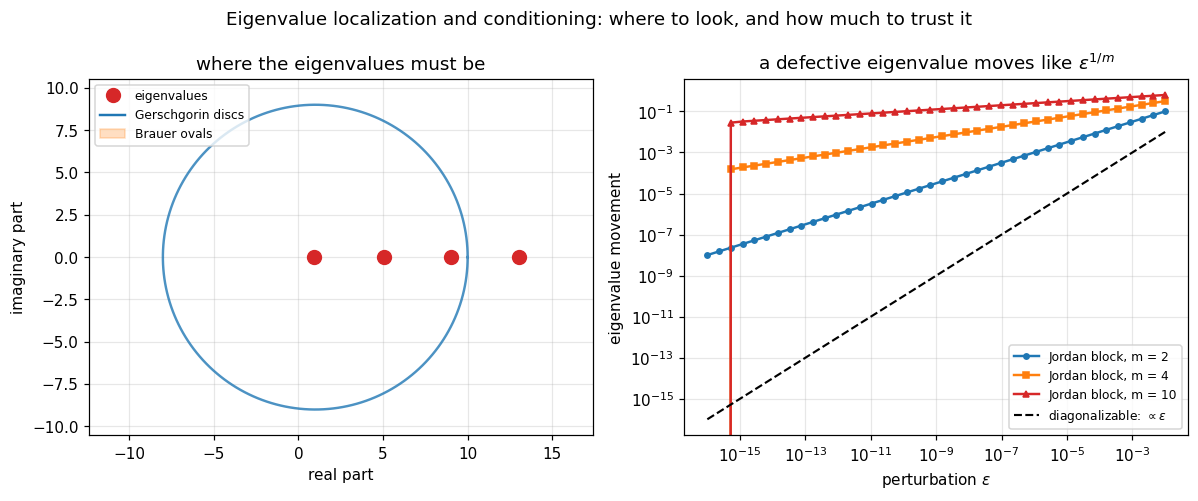

In [12]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6))

# left: Gerschgorin discs, Brauer ovals and the eigenvalues
show = lopsided
d_show = eigen.gerschgorin_discs(show)
vals_show = np.linalg.eigvals(show)
theta = np.linspace(0.0, 2.0 * np.pi, 200)
for d in d_show:
    axL.plot(d.centre.real + d.radius * np.cos(theta),
             d.centre.imag + d.radius * np.sin(theta), "C0-", lw=1.6, alpha=0.8)
    axL.plot(d.centre.real, d.centre.imag, "C0+", ms=8)

# the Brauer region, drawn by shading the points that satisfy the inequality
ovals_show = eigen.brauer_ovals(show)
lo = min(d.centre.real - d.radius for d in d_show) - 1.0
hi = max(d.centre.real + d.radius for d in d_show) + 1.0
rad = max(d.radius for d in d_show) + 1.0
gx, gy = np.meshgrid(np.linspace(lo, hi, 320), np.linspace(-rad, rad, 320))
inside = np.zeros_like(gx, dtype=bool)
for o in ovals_show:
    c_i, c_j, r_i, r_j = o
    z = gx + 1j * gy
    inside |= (np.abs(z - c_i) * np.abs(z - c_j)) <= r_i * r_j
axL.contourf(gx, gy, inside.astype(float), levels=[0.5, 1.5], colors=["C1"], alpha=0.25)
axL.plot(vals_show.real, vals_show.imag, "C3o", ms=9, label="eigenvalues")
axL.plot([], [], "C0-", lw=1.6, label="Gerschgorin discs")
axL.fill_between([], [], color="C1", alpha=0.25, label="Brauer ovals")
axL.set_xlabel("real part")
axL.set_ylabel("imaginary part")
axL.set_title("where the eigenvalues must be")
axL.legend(fontsize=8, loc="upper left")
axL.set_aspect("equal", adjustable="datalim")

# right: how far eigenvalues move, defective against diagonalizable
eps_grid = np.geomspace(1e-16, 1e-2, 40)
for block, style in ((2, "C0o-"), (4, "C1s-"), (10, "C3^-")):
    moved = [eigen.jordan_perturbation_spread(block, e)["moved"] for e in eps_grid]
    axR.loglog(eps_grid, moved, style, lw=1.6, ms=3.5,
               label=f"Jordan block, m = {block}")
axR.loglog(eps_grid, eps_grid, "k--", lw=1.4, label=r"diagonalizable: $\propto \varepsilon$")
axR.set_xlabel(r"perturbation $\varepsilon$")
axR.set_ylabel("eigenvalue movement")
axR.set_title(r"a defective eigenvalue moves like $\varepsilon^{1/m}$")
axR.legend(fontsize=8, loc="lower right")

fig.suptitle("Eigenvalue localization and conditioning: where to look, and how much to trust it",
             fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is section 7 in one image.** The dashed line is slope 1, what a well behaved
eigenvalue does. The Jordan curves have slopes $1/2$, $1/4$ and $1/10$, and at
$\varepsilon = 10^{-16}$ the $m = 10$ block has already moved by $0.03$.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Why does the existence of the companion matrix rule out a finite eigenvalue algorithm, and
what exactly does it not rule out?

1.2 Gerschgorin's discs contained every eigenvalue on every matrix in this lesson. Why is that
not enough to make the theorem useful, and what makes it useful when it is?

1.3 A matrix has $\kappa(A) = 3$ and one of its eigenvalues moves by $0.04$ under a perturbation
of $10^{-14}$. Explain how both can be true.

**Level 2, mathematical**

2.1 Prove Gerschgorin's theorem, and use the proof to characterise exactly when an eigenvalue
lies on the boundary of a disc.

2.2 Prove the disjoint disc refinement: if $k$ discs form a component disjoint from the rest,
that component contains exactly $k$ eigenvalues.

2.3 Prove that Brauer's union is contained in Gerschgorin's, and give a matrix where the
containment is strict.

2.4 Derive the first order perturbation $\delta\lambda = \mathbf{y}^HE\mathbf{x}/\mathbf{y}^H\mathbf{x}$
and hence the condition number $1/|\mathbf{y}^H\mathbf{x}|$. Then show it equals 1 for every
eigenvalue of a normal matrix.

2.5 Prove Bauer-Fike, and show by example that $\kappa(V)$ can be arbitrarily larger than the
worst individual condition number.

**Level 3, computational**

3.1 Implement **Gerschgorin with a diagonal similarity**: $D^{-1}AD$ has the same eigenvalues
and different discs, so choosing $D$ well shrinks the region. Optimise $D$ numerically and
measure how much the bound improves.

3.2 Implement the **Bendixson and Hirsch** bounds, which localise the real and imaginary parts
separately using the symmetric and skew parts of $A$, and compare their region against
Gerschgorin's on several families.

3.3 Implement **eigenvalue conditioning by finite differences**: perturb $A$ in many random
directions, measure the movement of each eigenvalue, and compare the measured sensitivity
against $1/|\mathbf{y}^H\mathbf{x}|$.

**Level 4, experimental**

4.1 Measure how loose Gerschgorin is against the degree of diagonal dominance. Build a family
interpolating from diagonal to full and fit the ratio of the region size to the true eigenvalue
spread.

4.2 Measure the transition from "diagonalizable" to "defective" behaviour. Take two eigenvalues
at distance $\delta$ and perturb by $\varepsilon$; find where the movement crosses over from
$\varepsilon$ to $\sqrt{\varepsilon}$, and check it against $\delta$.

4.3 Measure the overstatement of Bauer-Fike against the non-normality of the matrix, and
compare with the individual condition numbers. Fit which one predicts the actual movement.

**Level 5, advanced**

5.1 **Pseudospectra.** The set of $z$ that are eigenvalues of some $A+E$ with $\|E\|\le
\varepsilon$ is a far better description of a non-normal matrix than its eigenvalues. Compute
them, relate them to $\|(zI-A)^{-1}\|$, and explain what they say that condition numbers do not.

5.2 **Why the characteristic polynomial is never used.** Give at least three separate reasons,
compute an example for each, and explain the one case where forming it is defensible.

5.3 **The Bauer-Fike family.** There are sharper versions using the departure from normality
rather than $\kappa(V)$. State one, implement it, and find where it beats the classical bound and
where it does not.

## 11. Key takeaways

- **No finite algorithm computes eigenvalues**, because every polynomial is the characteristic
  polynomial of its companion matrix and Abel and Galois rule out radical formulas from degree 5.
  Every method in Part 6 is therefore iterative.
- **The companion matrix is a proof device, not a root finder.** Measured: $\kappa$ rises from
  52 at degree 2 to $6.3\times10^{5}$ at degree 12.
- **Gerschgorin's discs contain every eigenvalue**, and the three-line proof says exactly when
  the bound is tight: when the eigenvector is concentrated on one entry.
- **Disjoint discs upgrade the theorem to an exact count**, and a disc disjoint from all the
  others is a rigorous error bound on one eigenvalue.
- **The columns give a second free region**, since $A$ and $A^T$ share eigenvalues, and on the
  lopsided matrix here the column region is 3.0 times smaller by area than the row region.
- **Brauer's Cassini ovals are strictly contained in the Gerschgorin discs**, verified here by
  sampling 20000 points, at a cost of $n(n-1)/2$ regions instead of $n$.
- **Each eigenvalue has its own condition number** $1/|\mathbf{y}^H\mathbf{x}|$, and they
  differ: measured spanning a factor of 33 on one matrix.
- **Every eigenvalue of a symmetric matrix has condition number exactly 1.** That is why the
  symmetric problem is a separate and much easier subject.
- **Bauer-Fike holds and overstates**, by 2.7 to 12 times here, because it is a worst case over
  perturbation directions and $\kappa(V)$ is set by the worst eigenvalue and applied to all.
- **A defective eigenvalue moves like $\varepsilon^{1/m}$, not $\varepsilon$.** Measured exact to
  four decimals: at $m = 10$ and $\varepsilon = 10^{-14}$ the movement is $0.04$, an
  amplification of $4\times10^{12}$, on a matrix of zeros and ones.
- **So $\kappa(A)$ does not predict eigenvalue accuracy at all.** It is the wrong number for
  this problem, and the right ones are $1/|\mathbf{y}^H\mathbf{x}|$ and the eigenvalue gaps.
- **The Schur form always exists** and the eigendecomposition does not, which is why every
  algorithm targets it.
- **And every algorithm uses orthogonal similarities only**, because any similarity preserves
  the eigenvalues but only an orthogonal one preserves the conditioning. Measured: a graded
  similarity with $\kappa(S) = 10^{8}$ moves the eigenvalues by $1.5\times10^{-15}$ and takes
  $\kappa$ of the matrix from 13.2 to $2.8\times10^{14}$.

## Where this goes next

**Lesson 36** starts computing: power iteration and its rate, inverse iteration, shifts, and the
Rayleigh quotient whose convergence is cubic on a symmetric matrix.

**Lesson 37** builds the QR algorithm, which is the workhorse, and shows how it converges to the
Schur form of section 8 using only the orthogonal similarities of that section.

**Lesson 38** takes the symmetric case seriously, where section 5's condition number of 1 buys
algorithms that are both faster and unconditionally accurate.

**Lesson 41** builds the SVD, which Part 5 used on credit, and which turns out to be the
symmetric eigenvalue problem of $A^TA$ done without ever forming $A^TA$.